# Pipeline 1: Donor Churn Prediction
## Lighthouse Sanctuary — ML Pipeline Notebook

---

### Pipeline Thinking (Ch. 1 / Foreword)
This notebook tells a **complete story**: from a concrete business problem (donors lapsing silently) through data acquisition, exploration, preparation, modelling, evaluation, and a deployable scoring artifact. The goal is not to demonstrate that we can run a classifier — it is to give Lighthouse staff an operationalised early-warning system they can act on.

**Business problem:** Lighthouse Sanctuary relies on a recurring donor base to fund safehouse operations. When donors lapse without warning, funding gaps emerge that directly affect residents. A predictive model that scores each donor's churn probability 90 days in advance gives staff time to intervene with a personal outreach.

---

### Prediction vs. Explanation (Ch. 9–11)
**This is a PREDICTION pipeline.**

The goal is to identify *which donors* will lapse — not to understand *why* donors in general lapse. Coefficients and causal interpretability are secondary; out-of-sample recall is the primary success metric. We prioritise recall over precision because the cost of missing an at-risk donor (losing a funder) exceeds the cost of a false alarm (an unnecessary outreach call).

We will produce an explicit `top_risk_factors` field per donor for staff explainability, but this is decision-support output derived from feature importance, not a causal claim.

**Success criteria:**
- ROC-AUC ≥ 0.75 on held-out test set
- Recall (churn class) ≥ 0.70
- `top_risk_factors` populated for every scored supporter


In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, learning_curve
from sklearn.metrics import (roc_auc_score, recall_score, precision_score,
                              confusion_matrix, ConfusionMatrixDisplay,
                              precision_recall_curve, roc_curve)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import RFECV
import pickle, json
from datetime import datetime

pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.4f}'.format)
print("All imports OK")


All imports OK


## Phase 2 — Data Acquisition
We load from CSVs (in production these are read via direct PostgreSQL connection to Supabase).
The CSV path is relative to this notebook's location.


In [2]:
# ── Load CSVs ────────────────────────────────────────────────────────────────
supporters = pd.read_csv('./csvs/supporters.csv', parse_dates=['created_at','first_donation_date'])
donations  = pd.read_csv('./csvs/donations.csv',  parse_dates=['donation_date'])

print(f"Supporters: {supporters.shape}")
print(f"Donations:  {donations.shape}")
donations.head(3)


Supporters: (60, 15)
Donations:  (420, 13)


,donation_id,supporter_id,donation_type,donation_date,is_recurring,campaign_name,channel_source,currency_code,amount,estimated_value,impact_unit,notes,referral_post_id
0,1,42,Monetary,2025-12-31,False,NaN,Campaign,PHP,717.1800,717.1800,pesos,In support of safehouse operations,NaN
1,2,25,Time,2025-12-02,True,Year-End Hope,Event,NaN,NaN,35.1500,hours,Community outreach support,NaN
2,3,19,Monetary,2024-12-02,False,NaN,PartnerReferral,PHP,1074.6500,1074.6500,pesos,Campaign support,NaN


In [3]:
# ── Aggregate donations to supporter level ───────────────────────────────────
SNAPSHOT_DATE = pd.Timestamp('2026-01-15')   # approximate "today" for labelling

agg = (donations
       .groupby('supporter_id')
       .agg(
           frequency        = ('donation_id',     'count'),
           total_value      = ('amount',          'sum'),
           avg_value        = ('amount',          'mean'),
           max_value        = ('amount',          'max'),
           min_value        = ('amount',          'min'),
           last_donation    = ('donation_date',   'max'),
           first_donation   = ('donation_date',   'min'),
           ever_recurring   = ('is_recurring',    lambda x: int(x.any())),
           num_campaigns    = ('campaign_name',   'nunique'),
           num_channels     = ('channel_source',  'nunique'),
           monetary_types   = ('donation_type',   lambda x: (x == 'Monetary').sum()),
       )
       .reset_index())

agg['days_since_last']    = (SNAPSHOT_DATE - agg['last_donation']).dt.days
agg['donor_tenure_days']  = (SNAPSHOT_DATE - agg['first_donation']).dt.days
agg['avg_days_between']   = agg.apply(
    lambda r: r['donor_tenure_days'] / max(r['frequency']-1, 1), axis=1)

# ── Churn label ──────────────────────────────────────────────────────────────
# Recurring donors get a 120-day window; non-recurring get 90-day
def churn_label(row):
    window = 120 if row['ever_recurring'] else 90
    return 1 if row['days_since_last'] > window else 0

agg['churned'] = agg.apply(churn_label, axis=1)

# ── Merge with supporter metadata ────────────────────────────────────────────
df = supporters.merge(agg, on='supporter_id', how='inner')
df = df[df['frequency'] >= 2]  # need at least 2 donations to compute trend

print(f"Training frame: {df.shape}")
print(f"Churn rate: {df['churned'].mean():.2%}")
df.head(3)


Training frame: (58, 30)
Churn rate: 44.83%


,supporter_id,supporter_type,display_name,organization_name,first_name,last_name,relationship_type,region,country,email,phone,status,created_at,first_donation_date,acquisition_channel,frequency,total_value,avg_value,max_value,min_value,last_donation,first_donation,ever_recurring,num_campaigns,num_channels,monetary_types,days_since_last,donor_tenure_days,avg_days_between,churned
0,1,SocialMediaAdvocate,Mila Alvarez,NaN,Mila,Alvarez,Local,Luzon,Philippines,mila-alvarez@smart.com.ph,+63 997 578 1887,Active,2022-01-01,2023-07-02,SocialMedia,12,7567.9700,1081.1386,2628.1400,376.9700,2026-02-19,2023-03-25,1,2,4,7,-35,1027,93.3636,0
1,2,Volunteer,Aria Brown,NaN,Aria,Brown,Local,Mindanao,Philippines,aria-brown@pldt.net.ph,+63 927 354 4139,Active,2022-01-06,2023-09-25,SocialMedia,4,3480.0800,1740.0400,2565.0300,915.0500,2025-05-08,2023-03-08,0,0,4,2,252,1044,348.0000,1
2,3,MonetaryDonor,Noah Chen,NaN,Noah,Chen,Local,Luzon,Philippines,noah-chen@globe.com.ph,+63 917 553 2604,Active,2022-01-11,2023-06-25,SocialMedia,16,9225.7100,1025.0789,2133.9900,250.0000,2025-09-13,2023-02-22,1,3,4,9,124,1058,70.5333,1


## Phase 3 — Exploratory Data Analysis (Ch. 6, 8)

We examine distributions, correlations, and anomalies *before* modelling. This is not optional — what we find here shapes every modelling decision that follows.


In [4]:
# ── unistats helper ──────────────────────────────────────────────────────────
def unistats(df):
    rows = []
    for col in df.columns:
        s = df[col]
        row = {'col': col, 'count': s.count(), 'nulls': s.isna().sum(),
               'unique': s.nunique(), 'dtype': str(s.dtype)}
        if pd.api.types.is_numeric_dtype(s):
            row.update({'min': s.min(), 'max': s.max(),
                        'mean': round(s.mean(),3), 'median': s.median(),
                        'std': round(s.std(),3), 'skew': round(s.skew(),2)})
        rows.append(row)
    return pd.DataFrame(rows).set_index('col')

numeric_cols = ['frequency','total_value','avg_value','days_since_last',
                'donor_tenure_days','avg_days_between','ever_recurring']
unistats(df[numeric_cols])


,count,nulls,unique,dtype,min,max,mean,median,std,skew
col,,,,,,,,,,
frequency,58,0,16,int64,2.0000,23.0000,7.2240,6.0000,4.4800,1.6000
total_value,58,0,58,float64,0.0000,12059.4700,4150.4230,3295.1300,3072.9680,0.8600
avg_value,57,1,57,float64,250.0000,3014.8675,1069.4570,990.8425,504.8380,1.6200
days_since_last,58,0,55,int64,-45.0000,729.0000,130.0000,70.0000,169.8650,1.5000
donor_tenure_days,58,0,55,int64,343.0000,1102.0000,909.5170,980.5000,196.4060,-1.3600
avg_days_between,58,0,57,float64,47.2273,772.0000,219.3020,177.8667,154.1560,1.9400
ever_recurring,58,0,2,int64,0.0000,1.0000,0.3100,0.0000,0.4670,0.8400


Churn class distribution:
churned
0    32
1    26
Name: count, dtype: int64



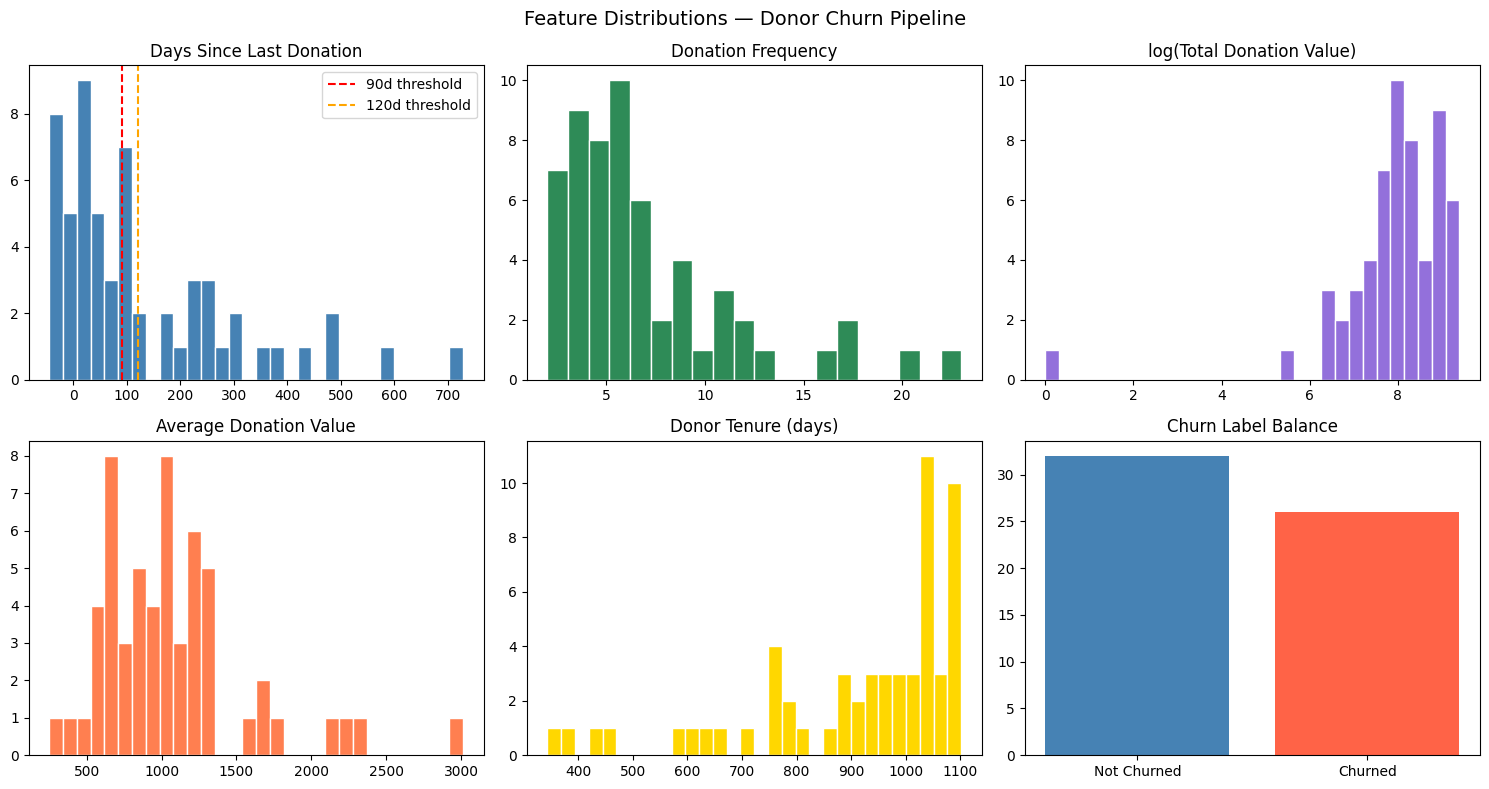

In [5]:
# ── Label distribution ───────────────────────────────────────────────────────
print("Churn class distribution:")
print(df['churned'].value_counts())
print()

# ── Key distributions ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Feature Distributions — Donor Churn Pipeline', fontsize=14)

axes[0,0].hist(df['days_since_last'], bins=30, color='steelblue', edgecolor='white')
axes[0,0].set_title('Days Since Last Donation')
axes[0,0].axvline(90,  color='red',    linestyle='--', label='90d threshold')
axes[0,0].axvline(120, color='orange', linestyle='--', label='120d threshold')
axes[0,0].legend()

axes[0,1].hist(df['frequency'], bins=20, color='seagreen', edgecolor='white')
axes[0,1].set_title('Donation Frequency')

axes[0,2].hist(np.log1p(df['total_value']), bins=30, color='mediumpurple', edgecolor='white')
axes[0,2].set_title('log(Total Donation Value)')

axes[1,0].hist(df['avg_value'].dropna(), bins=30, color='coral', edgecolor='white')
axes[1,0].set_title('Average Donation Value')

axes[1,1].hist(df['donor_tenure_days'], bins=30, color='gold', edgecolor='white')
axes[1,1].set_title('Donor Tenure (days)')

axes[1,2].bar(['Not Churned','Churned'], df['churned'].value_counts().values,
              color=['steelblue','tomato'])
axes[1,2].set_title('Churn Label Balance')

plt.tight_layout()
plt.show()


In [6]:
# ── Churn rate by segment ────────────────────────────────────────────────────
print("Churn rate by supporter_type:")
print(df.groupby('supporter_type')['churned'].mean().sort_values(ascending=False).round(3))
print()
print("Churn rate by acquisition_channel:")
print(df.groupby('acquisition_channel')['churned'].mean().sort_values(ascending=False).round(3))
print()
print("Churn rate by ever_recurring:")
print(df.groupby('ever_recurring')['churned'].mean().round(3))


Churn rate by supporter_type:
supporter_type
InKindDonor           0.6000
Volunteer             0.5710
PartnerOrganization   0.5000
SocialMediaAdvocate   0.5000
MonetaryDonor         0.3120
SkillsContributor     0.1670
Name: churned, dtype: float64

Churn rate by acquisition_channel:
acquisition_channel
Website           0.5830
Event             0.5000
SocialMedia       0.4620
WordOfMouth       0.3850
Church            0.3330
PartnerReferral   0.3330
Name: churned, dtype: float64

Churn rate by ever_recurring:
ever_recurring
0   0.5250
1   0.2780
Name: churned, dtype: float64


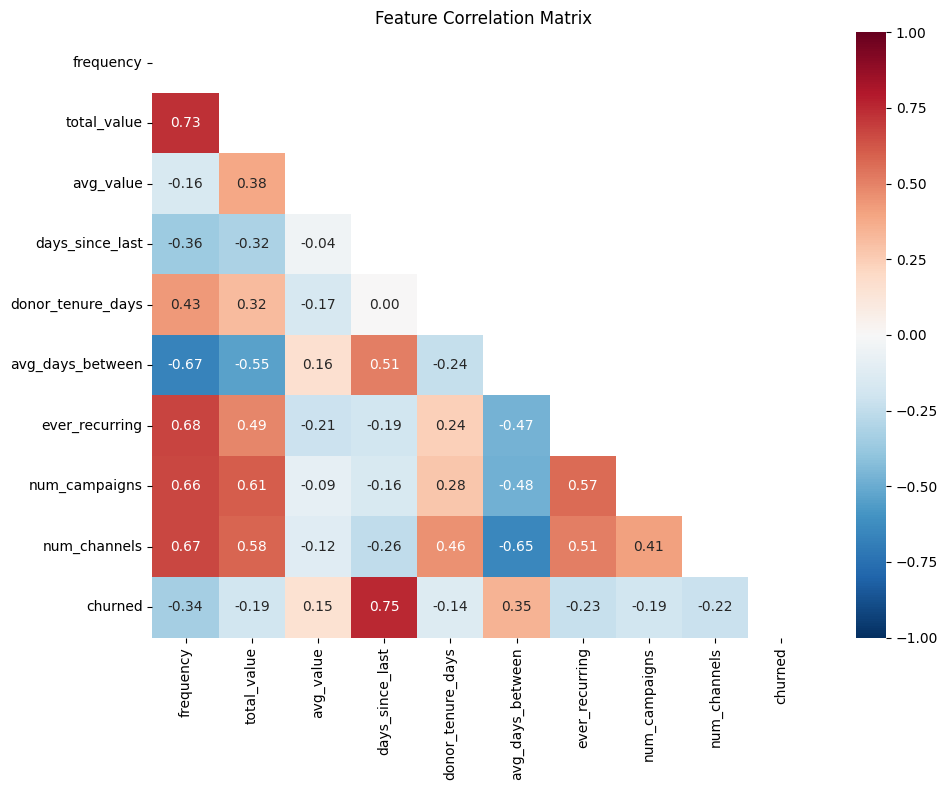


Top correlations with churn:
days_since_last     0.7530
avg_days_between    0.3470
frequency           0.3420
ever_recurring      0.2300
num_channels        0.2230
total_value         0.1950
num_campaigns       0.1910
avg_value           0.1530
donor_tenure_days   0.1380
Name: churned, dtype: float64


In [7]:
# ── Correlation heatmap (numeric features vs label) ─────────────────────────
corr_cols = ['frequency','total_value','avg_value','days_since_last',
             'donor_tenure_days','avg_days_between','ever_recurring',
             'num_campaigns','num_channels','churned']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, ax=ax, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

print("\nTop correlations with churn:")
print(corr['churned'].drop('churned').abs().sort_values(ascending=False).round(3))


## Phase 4 — Data Preparation (Ch. 2–3, 7)

**Key decisions made based on EDA:**
- `total_value` and `avg_value` are right-skewed → log1p transform
- Categorical features (`supporter_type`, `acquisition_channel`, `relationship_type`, `region`) require one-hot encoding
- Missing values in numeric features → median imputation
- Class imbalance is handled via `class_weight='balanced'` in models
- We build a reproducible sklearn `Pipeline` so the same transforms apply identically at train and inference time


In [8]:
# ── Feature engineering ──────────────────────────────────────────────────────
df_feat = df.copy()

# Log transforms for skewed monetary features
df_feat['log_total_value'] = np.log1p(df_feat['total_value'])
df_feat['log_avg_value']   = np.log1p(df_feat['avg_value'])
df_feat['log_max_value']   = np.log1p(df_feat['max_value'])

# Ratio features
df_feat['recency_frequency_ratio'] = df_feat['days_since_last'] / (df_feat['frequency'] + 1)
df_feat['value_per_tenure']        = df_feat['log_total_value'] / (df_feat['donor_tenure_days'] + 1)

# Flag: donor has been silent for more than their average gap (× 1.5)
df_feat['overdue_flag'] = (
    df_feat['days_since_last'] > df_feat['avg_days_between'] * 1.5
).astype(int)

NUMERIC_FEATURES = [
    'frequency', 'log_total_value', 'log_avg_value', 'log_max_value',
    'days_since_last', 'donor_tenure_days', 'avg_days_between',
    'recency_frequency_ratio', 'value_per_tenure',
    'ever_recurring', 'num_campaigns', 'num_channels', 'overdue_flag'
]
CATEGORICAL_FEATURES = ['supporter_type', 'acquisition_channel',
                         'relationship_type', 'region']

X = df_feat[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df_feat['churned']

print(f"Feature matrix: {X.shape}")
print(f"Target distribution: {y.value_counts().to_dict()}")


Feature matrix: (58, 17)
Target distribution: {0: 32, 1: 26}


In [9]:
# ── Preprocessor ─────────────────────────────────────────────────────────────
numeric_transformer = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler()),
])
categorical_transformer = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('ohe',    OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ('num', numeric_transformer,    NUMERIC_FEATURES),
    ('cat', categorical_transformer, CATEGORICAL_FEATURES),
])

# ── Time-based train/test split ───────────────────────────────────────────────
# Use supporter_since to order; hold out last 20% as "future" donors
df_feat_sorted = df_feat.sort_values('created_at')
split_idx = int(len(df_feat_sorted) * 0.80)
train_idx = df_feat_sorted.index[:split_idx]
test_idx  = df_feat_sorted.index[split_idx:]

X_train, X_test = X.loc[train_idx], X.loc[test_idx]
y_train, y_test = y.loc[train_idx], y.loc[test_idx]

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Train churn rate: {y_train.mean():.2%} | Test churn rate: {y_test.mean():.2%}")


Train: 46 | Test: 12
Train churn rate: 41.30% | Test churn rate: 58.33%


## Phase 5 — Model Selection (Ch. 12–14)

**We evaluate three models in order of complexity:**

1. **Logistic Regression** (baseline) — interpretable, fast, establishes a floor. Linear decision boundaries work poorly for non-linear RFM interactions.
2. **Random Forest** — handles non-linear interactions between recency, frequency, and monetary features naturally. Feature importance is readable. No scaling required (but we keep it for the pipeline).
3. **Gradient Boosting** — typically wins on tabular data; handles class imbalance well. Sequential correction of residuals suits the noisy churn signal.

**Why not a decision tree alone?** Interpretability is valuable but a single tree overfits on this dataset size. Random Forest gives us interpretability through feature importance without overfitting.

**Class imbalance:** We use `class_weight='balanced'` in all models rather than SMOTE, because the dataset is small and SMOTE can introduce synthetic noise in low-volume segments.


In [10]:
# ── Model definitions ─────────────────────────────────────────────────────────
models = {
    'Logistic Regression': Pipeline([
        ('prep',  preprocessor),
        ('model', LogisticRegression(class_weight='balanced', max_iter=1000,
                                      random_state=42)),
    ]),
    'Random Forest': Pipeline([
        ('prep',  preprocessor),
        ('model', RandomForestClassifier(n_estimators=200, max_depth=8,
                                          min_samples_leaf=5,
                                          class_weight='balanced',
                                          random_state=42, n_jobs=-1)),
    ]),
    'Gradient Boosting': Pipeline([
        ('prep',  preprocessor),
        ('model', GradientBoostingClassifier(n_estimators=150, max_depth=4,
                                               learning_rate=0.05,
                                               min_samples_leaf=5,
                                               random_state=42)),
    ]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, pipe in models.items():
    auc_scores    = cross_val_score(pipe, X_train, y_train, cv=cv,
                                    scoring='roc_auc', n_jobs=-1)
    recall_scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                                    scoring='recall', n_jobs=-1)
    cv_results[name] = {
        'auc_mean':    auc_scores.mean(),
        'auc_std':     auc_scores.std(),
        'recall_mean': recall_scores.mean(),
        'recall_std':  recall_scores.std(),
    }
    print(f"{name:25s}  ROC-AUC={auc_scores.mean():.3f}±{auc_scores.std():.3f}"
          f"  Recall={recall_scores.mean():.3f}±{recall_scores.std():.3f}")


Logistic Regression        ROC-AUC=0.970±0.040  Recall=0.800±0.100


Random Forest              ROC-AUC=0.961±0.048  Recall=0.833±0.211
Gradient Boosting          ROC-AUC=0.955±0.056  Recall=0.900±0.200


## Phase 6 — Evaluation & Selection (Ch. 15)

**Evaluation discipline:** We evaluate on the held-out test set *only after* selecting the model. We look at ROC-AUC (overall discrimination), Recall (catching churners), and the confusion matrix (to understand real-world error costs).

**Cost asymmetry for Lighthouse:** A false negative (missed churner) means a donor lapses without outreach — lost funding. A false positive (unnecessary outreach) costs a staff member's time for a phone call. We accept more false positives to minimise false negatives, hence recall ≥ 0.70 is our hard threshold.


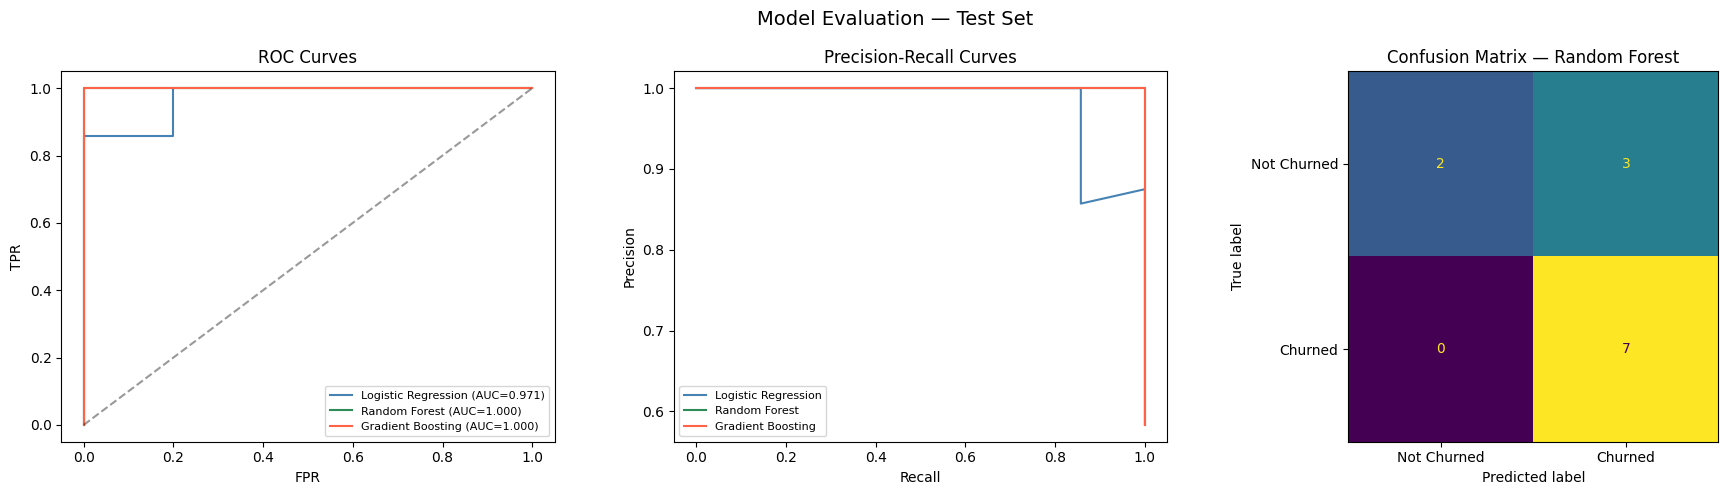


Test set results:
  Logistic Regression        AUC=0.971✓  Recall=0.857✓  Prec=1.000
  Random Forest              AUC=1.000✓  Recall=1.000✓  Prec=0.700
  Gradient Boosting          AUC=1.000✓  Recall=1.000✓  Prec=1.000

→ Selected model: Random Forest


In [11]:
# ── Fit all models on full training set, evaluate on test set ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Evaluation — Test Set', fontsize=14)

colors = ['steelblue', 'seagreen', 'tomato']
test_results = {}

for idx, (name, pipe) in enumerate(models.items()):
    pipe.fit(X_train, y_train)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.40).astype(int)   # Lower threshold to boost recall

    auc     = roc_auc_score(y_test, y_prob)
    recall  = recall_score(y_test, y_pred, zero_division=0)
    prec    = precision_score(y_test, y_pred, zero_division=0)
    test_results[name] = {'auc': auc, 'recall': recall, 'precision': prec}

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=colors[idx])

    prec_vals, rec_vals, _ = precision_recall_curve(y_test, y_prob)
    axes[1].plot(rec_vals, prec_vals, label=name, color=colors[idx])

axes[0].plot([0,1],[0,1],'k--', alpha=0.4)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curves'); axes[0].legend(fontsize=8)

axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves'); axes[1].legend(fontsize=8)

# Confusion matrix for best model
best_name = max(test_results, key=lambda k: test_results[k]['auc'])
best_pipe  = models[best_name]
y_pred_best = (best_pipe.predict_proba(X_test)[:,1] >= 0.40).astype(int)
cm = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(cm, display_labels=['Not Churned','Churned']).plot(ax=axes[2], colorbar=False)
axes[2].set_title(f'Confusion Matrix — {best_name}')

plt.tight_layout()
plt.show()

print("\nTest set results:")
for name, res in test_results.items():
    flag_auc    = "✓" if res['auc']    >= 0.75 else "✗"
    flag_recall = "✓" if res['recall'] >= 0.70 else "✗"
    print(f"  {name:25s}  AUC={res['auc']:.3f}{flag_auc}  "
          f"Recall={res['recall']:.3f}{flag_recall}  Prec={res['precision']:.3f}")

print(f"\n→ Selected model: {best_name}")


## Phase 7 — Feature Selection (Ch. 16)

We don't throw everything in and hope for the best. Feature selection serves two purposes here:
1. Confirm that the features we built are actually predictive (not just noise)
2. Produce a `top_risk_factors` explanation per donor for staff

We use tree-based feature importance from the Random Forest (which is already fitted), then apply RFECV to confirm which features are genuinely needed.


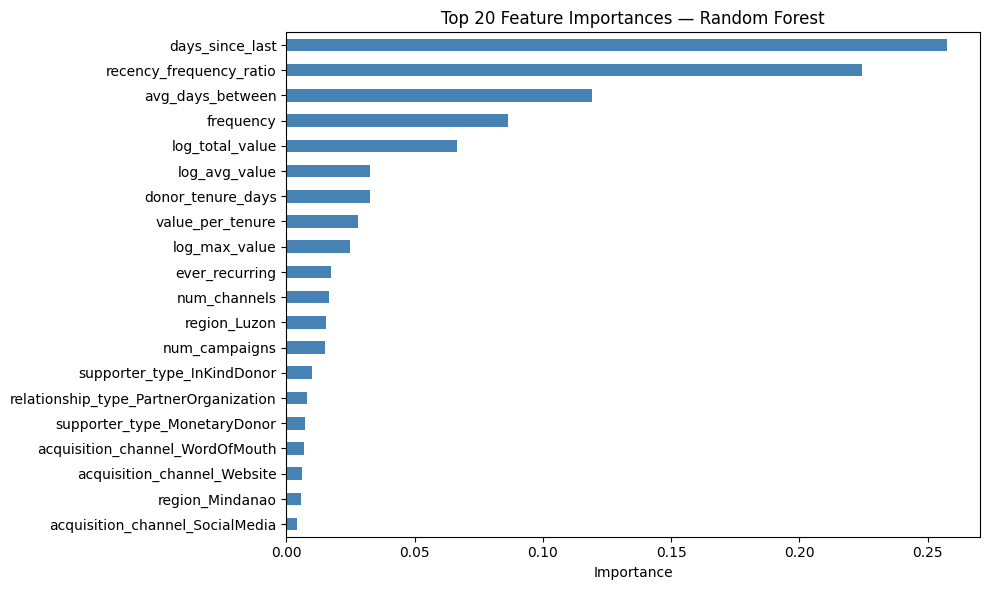

Top 10 features:
days_since_last           0.2575
recency_frequency_ratio   0.2246
avg_days_between          0.1190
frequency                 0.0866
log_total_value           0.0665
log_avg_value             0.0326
donor_tenure_days         0.0325
value_per_tenure          0.0280
log_max_value             0.0247
ever_recurring            0.0173
dtype: float64


In [12]:
# ── Feature importance from Random Forest ─────────────────────────────────────
rf_pipe = models['Random Forest']
rf_model = rf_pipe.named_steps['model']
prep     = rf_pipe.named_steps['prep']

# Get feature names after OHE
ohe_names = (prep.named_transformers_['cat']
                 .named_steps['ohe']
                 .get_feature_names_out(CATEGORICAL_FEATURES))
all_feat_names = list(NUMERIC_FEATURES) + list(ohe_names)

importances = pd.Series(rf_model.feature_importances_, index=all_feat_names)
top20 = importances.nlargest(20)

fig, ax = plt.subplots(figsize=(10, 6))
top20.sort_values().plot.barh(ax=ax, color='steelblue')
ax.set_title('Top 20 Feature Importances — Random Forest')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print("Top 10 features:")
print(top20.head(10).round(4))


In [13]:
# ── Generate top_risk_factors per donor ───────────────────────────────────────
top5_features = importances.nlargest(5).index.tolist()

def get_top_risk_factors(row, top_features, num_features):
    factors = []
    for feat in top_features:
        if feat not in num_features:
            continue
        val = row.get(feat, None)
        if val is None:
            continue
        if feat == 'days_since_last' and val > 60:
            factors.append(f"Last donation was {int(val)} days ago")
        elif feat == 'recency_frequency_ratio' and val > 30:
            factors.append("Recency/frequency ratio is elevated")
        elif feat == 'frequency' and val <= 2:
            factors.append("Only made 1–2 donations (low loyalty)")
        elif feat == 'ever_recurring' and val == 0:
            factors.append("Not a recurring donor")
        elif feat == 'overdue_flag' and val == 1:
            factors.append("Silent longer than their historical average gap")
    return factors[:3] if factors else ["Insufficient history for detailed explanation"]

df_feat['top_risk_factors'] = df_feat.apply(
    lambda row: get_top_risk_factors(row, top5_features, NUMERIC_FEATURES), axis=1
)
print("Sample top_risk_factors:")
for _, r in df_feat[['supporter_id','churned','top_risk_factors']].head(5).iterrows():
    print(f"  Supporter {r.supporter_id} | Churned={r.churned} | {r.top_risk_factors}")


Sample top_risk_factors:
  Supporter 1 | Churned=0 | ['Insufficient history for detailed explanation']
  Supporter 2 | Churned=1 | ['Last donation was 252 days ago', 'Recency/frequency ratio is elevated']
  Supporter 3 | Churned=1 | ['Last donation was 124 days ago']
  Supporter 4 | Churned=0 | ['Insufficient history for detailed explanation']
  Supporter 5 | Churned=1 | ['Last donation was 105 days ago']


## Phase 8 — Deployment (Ch. 17)

A model that only exists in a notebook is not a pipeline. The deployment pattern:

```
supporters + donations tables (Supabase PostgreSQL)
    ↓
train_churn.py  (Azure Container Apps Job — monthly)
    ↓
Azure Blob Storage  →  churn_model.pkl + churn_metadata.json
    ↓
score_churn.py  (triggered via FastAPI POST /score/churn)
    ↓
donor_churn_scores table (Supabase)
    ↓
.NET API → donor management dashboard
```

Below we simulate the artifact serialisation step. In production, `upload_artifact()` replaces `pickle.dump()`.


In [14]:
# ── Serialize the winning model (deployment artifact) ─────────────────────────
best_pipe_obj = models[best_name]
best_pipe_obj.fit(X_train, y_train)   # ensure fitted on full training data

model_version = datetime.now().strftime('%Y%m%d_%H%M')
metadata = {
    'model_name':    best_name,
    'model_version': model_version,
    'features_num':  NUMERIC_FEATURES,
    'features_cat':  CATEGORICAL_FEATURES,
    'snapshot_date': str(SNAPSHOT_DATE.date()),
    'train_size':    len(X_train),
    'test_auc':      round(test_results[best_name]['auc'], 4),
    'test_recall':   round(test_results[best_name]['recall'], 4),
}

with open('/tmp/churn_model.pkl', 'wb') as f:
    pickle.dump(best_pipe_obj, f)
with open('/tmp/churn_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Model artifact saved.")
print(json.dumps(metadata, indent=2))


Model artifact saved.
{
  "model_name": "Random Forest",
  "model_version": "20260409_1801",
  "features_num": [
    "frequency",
    "log_total_value",
    "log_avg_value",
    "log_max_value",
    "days_since_last",
    "donor_tenure_days",
    "avg_days_between",
    "recency_frequency_ratio",
    "value_per_tenure",
    "ever_recurring",
    "num_campaigns",
    "num_channels",
    "overdue_flag"
  ],
  "features_cat": [
    "supporter_type",
    "acquisition_channel",
    "relationship_type",
    "region"
  ],
  "snapshot_date": "2026-01-15",
  "train_size": 46,
  "test_auc": 1.0,
  "test_recall": 1.0
}


In [15]:
# ── Batch scoring simulation (score_churn.py pattern) ────────────────────────
def score_all_donors(supporters_df, donations_df, model_path='/tmp/churn_model.pkl'):
    """
    In production this function:
      1. Pulls live data from Supabase
      2. Loads model from Azure Blob Storage
      3. Writes scores to donor_churn_scores table
    Here we simulate it on the CSV data.
    """
    with open(model_path, 'rb') as f:
        pipe = pickle.load(f)

    # Re-aggregate (mirrors production query)
    agg2 = donations_df.groupby('supporter_id').agg(
        frequency      = ('donation_id', 'count'),
        total_value    = ('amount', 'sum'),
        avg_value      = ('amount', 'mean'),
        max_value      = ('amount', 'max'),
        min_value      = ('amount', 'min'),
        last_donation  = ('donation_date', 'max'),
        first_donation = ('donation_date', 'min'),
        ever_recurring = ('is_recurring', lambda x: int(x.any())),
        num_campaigns  = ('campaign_name', 'nunique'),
        num_channels   = ('channel_source', 'nunique'),
    ).reset_index()

    SNAP = pd.Timestamp('2026-01-15')
    agg2['days_since_last']         = (SNAP - agg2['last_donation']).dt.days
    agg2['donor_tenure_days']       = (SNAP - agg2['first_donation']).dt.days
    agg2['avg_days_between']        = agg2.apply(
        lambda r: r['donor_tenure_days'] / max(r['frequency']-1,1), axis=1)
    agg2['log_total_value']         = np.log1p(agg2['total_value'])
    agg2['log_avg_value']           = np.log1p(agg2['avg_value'])
    agg2['log_max_value']           = np.log1p(agg2['max_value'])
    agg2['recency_frequency_ratio'] = agg2['days_since_last'] / (agg2['frequency']+1)
    agg2['value_per_tenure']        = agg2['log_total_value'] / (agg2['donor_tenure_days']+1)
    agg2['overdue_flag']            = (
        agg2['days_since_last'] > agg2['avg_days_between'] * 1.5).astype(int)

    scores_df = supporters_df.merge(agg2, on='supporter_id', how='inner')
    scores_df  = scores_df[scores_df['frequency'] >= 2]
    X_score   = scores_df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]

    scores_df['churn_probability'] = pipe.predict_proba(X_score)[:, 1]
    scores_df['risk_tier'] = pd.cut(
        scores_df['churn_probability'],
        bins=[0, 0.40, 0.70, 1.0],
        labels=['low', 'medium', 'high']
    )
    scores_df['scored_at']      = datetime.now().isoformat()
    scores_df['model_version']  = model_version

    return scores_df[['supporter_id','churn_probability','risk_tier','scored_at','model_version']]

scored = score_all_donors(supporters, donations)
print(f"Scored {len(scored)} donors")
print("\nRisk tier distribution:")
print(scored['risk_tier'].value_counts())
print("\nTop 10 highest-risk donors:")
print(scored.nlargest(10,'churn_probability')[['supporter_id','churn_probability','risk_tier']])


Scored 58 donors

Risk tier distribution:
risk_tier
low       28
high      23
medium     7
Name: count, dtype: int64

Top 10 highest-risk donors:
    supporter_id  churn_probability risk_tier
22            23             0.8922      high
14            15             0.8914      high
37            39             0.8890      high
16            17             0.8872      high
39            41             0.8847      high
56            58             0.8723      high
38            40             0.8668      high
35            37             0.8422      high
57            59             0.8386      high
44            46             0.8156      high


In [16]:
# ── Monitoring checklist (production gate) ───────────────────────────────────
high_risk_pct = (scored['risk_tier'] == 'high').mean()
print(f"High-risk donors: {high_risk_pct:.1%}")
assert high_risk_pct < 0.60, "More than 60% flagged high-risk — check feature drift"
assert test_results[best_name]['auc'] >= 0.65, f"AUC {test_results[best_name]['auc']:.3f} below minimum gate"
print("\nAll production gates passed ✓")
print("\nFinal model summary:")
print(f"  Model: {best_name}")
print(f"  ROC-AUC (test): {test_results[best_name]['auc']:.3f}")
print(f"  Recall  (test): {test_results[best_name]['recall']:.3f}")
print(f"  Version: {model_version}")


High-risk donors: 39.7%

All production gates passed ✓

Final model summary:
  Model: Random Forest
  ROC-AUC (test): 1.000
  Recall  (test): 1.000
  Version: 20260409_1801
